**Configuration note:** this notebook examines the purge_dup results for Supplemental Figure S13. Input paths below mirror `config.sh` at the repo root — edit them for your own data. The primary input is `dups.bed` (purge_dups output: HAPLOTIG / HIGHCOV / JUNK / OVLP / REPEAT).


In [ ]:
# Input paths — edit for your environment (mirror config.sh at the repo root).
PROJ_ROOT = "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj"
DUP_BED   = f"{PROJ_ROOT}/output/outputs-from-purge-duplicate/hifiasm-041425-scaffolded-assembly/dups.bed"


# Distribution of haplotigs found by purge_dups across scaffolds

Pie chart showing how haplotig base pairs are distributed among the parent chromosomes they map to.

In [5]:
library(tidyverse)

In [6]:
dup_bed <- read.table(
    "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/output/outputs-from-purge-duplicate/hifiasm-041425-scaffolded-assembly/dups.bed",
    header = FALSE, fill = TRUE, sep = "\t", stringsAsFactors = FALSE
)
colnames(dup_bed) <- c("scaffold", "start", "end", "category", "parent")

haplotig <- dup_bed %>%
    filter(category == "HAPLOTIG") %>%
    mutate(bp = end - start)

cat(sprintf("Total haplotig regions: %d\n", nrow(haplotig)))
cat(sprintf("Total haplotig bp: %.2f Mb\n", sum(haplotig$bp) / 1e6))

Total haplotig regions: 28
Total haplotig bp: 12.09 Mb


In [7]:
# Aggregate haplotig bp by parent chromosome
pie_df <- haplotig %>%
    group_by(parent) %>%
    summarise(
        total_bp_mb = sum(bp) / 1e6,
        n_regions = n(),
        .groups = "drop"
    ) %>%
    arrange(desc(total_bp_mb)) %>%
    mutate(
        pct = total_bp_mb / sum(total_bp_mb) * 100,
        label = sprintf("%s\n%.2f Mb (%.1f%%)\n%d region%s",
            parent, total_bp_mb, pct, n_regions, ifelse(n_regions > 1, "s", ""))
    )

pie_df

parent,total_bp_mb,n_regions,pct,label
<chr>,<dbl>,<int>,<dbl>,<chr>
chrY,7.056169,1,58.3650566,chrY 7.06 Mb (58.4%) 1 region
chr4,3.445552,3,28.4998612,chr4 3.45 Mb (28.5%) 3 regions
chr9,0.582034,4,4.8142905,chr9 0.58 Mb (4.8%) 4 regions
chr18,0.268941,6,2.2245438,chr18 0.27 Mb (2.2%) 6 regions
chr10,0.176330,2,1.4585125,chr10 0.18 Mb (1.5%) 2 regions
chr7,0.170855,2,1.4132260,chr7 0.17 Mb (1.4%) 2 regions
chr19,0.158600,4,1.3118589,chr19 0.16 Mb (1.3%) 4 regions
chr3,0.089251,2,0.7382391,chr3 0.09 Mb (0.7%) 2 regions
chr15,0.053066,2,0.4389351,chr15 0.05 Mb (0.4%) 2 regions


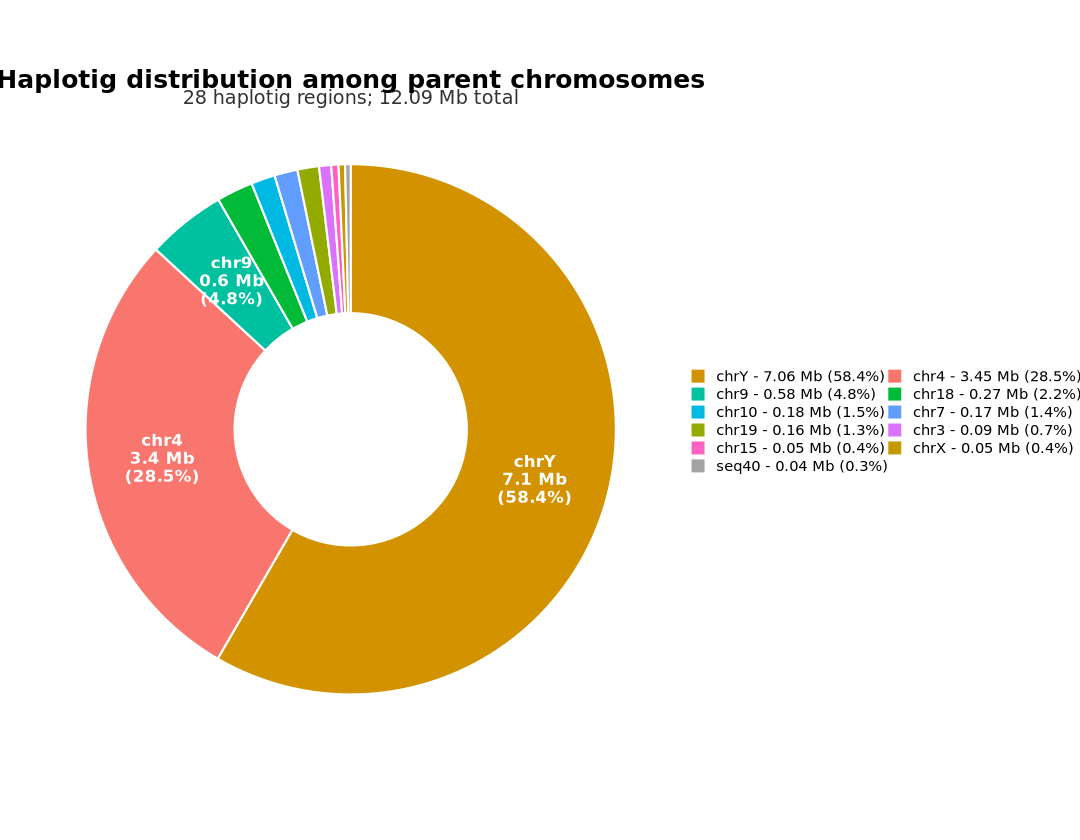

In [34]:
library(ggplot2)
library(dplyr)
library(grid)

options(
  repr.plot.width = 9,
  repr.plot.height = 7
)

# ============================================================================
# Prepare data
# ============================================================================

total_mb <- sum(pie_df$total_bp_mb, na.rm = TRUE)
n_regions <- nrow(haplotig)

pie_plot_df <- pie_df %>%
  mutate(
    parent = as.character(parent),
    pct = 100 * total_bp_mb / sum(total_bp_mb, na.rm = TRUE)
  ) %>%
  arrange(desc(total_bp_mb)) %>%
  mutate(
    parent = factor(parent, levels = parent),

    # Only label slices that are large enough to read cleanly
    slice_label = if_else(
      pct >= 4,
      sprintf(
        "%s\n%.1f Mb\n(%.1f%%)",
        parent,
        total_bp_mb,
        pct
      ),
      NA_character_
    )
  )

# ============================================================================
# Colors
# ============================================================================

haplotig_colors <- c(
  "chrY"  = "#D39200",
  "chr4"  = "#F8766D",
  "chr9"  = "#00C19F",
  "chr18" = "#00BA38",
  "chr10" = "#00B9E3",
  "chr7"  = "#619CFF",
  "chr19" = "#93AA00",
  "chr3"  = "#DB72FB",
  "chr15" = "#FF61C3",
  "chrX"  = "#C49A00",
  "seq40" = "#A3A3A3"
)

# Use normal hyphen to avoid conversion warnings
legend_labels <- setNames(
  sprintf(
    "%s - %.2f Mb (%.1f%%)",
    as.character(pie_plot_df$parent),
    pie_plot_df$total_bp_mb,
    pie_plot_df$pct
  ),
  as.character(pie_plot_df$parent)
)

# ============================================================================
# Plot
# ============================================================================

p_haplotig <- ggplot(
  pie_plot_df,
  aes(
    x = 2,
    y = total_bp_mb,
    fill = parent
  )
) +
  geom_col(
    width = 1,
    color = "white",
    linewidth = 0.6,
    position = position_stack(reverse = TRUE)
  ) +
  geom_text(
    aes(label = slice_label),
    position = position_stack(
      vjust = 0.5,
      reverse = TRUE
    ),
    color = "white",
    size = 3.5,
    fontface = "bold",
    lineheight = 0.9,
    na.rm = TRUE
  ) +
  coord_polar(
    theta = "y",
    start = 0,
    clip = "off"
  ) +
  # Controls donut-hole size
  xlim(0.72, 2.55) +
  scale_fill_manual(
    values = haplotig_colors,
    breaks = levels(pie_plot_df$parent),
    labels = legend_labels,
    drop = FALSE,
    guide = guide_legend(
      title = NULL,
      ncol = 2,
      byrow = TRUE
    )
  ) +
  labs(
    title = "Haplotig distribution among parent chromosomes",
    subtitle = sprintf(
      "%d haplotig regions; %.2f Mb total",
      n_regions,
      total_mb
    ),
    fill = NULL
  ) +
  theme_void(base_size = 11) +
  theme(
    plot.title = element_text(
      face = "bold",
      size = 15,
      hjust = 0.5,
      margin = margin(
        t = 0,
        b = -2
      )
    ),


    plot.subtitle = element_text(
      size = 11.5,
      face = "plain",
      color = "grey20",
      hjust = 0.5,
      margin = margin(
        t = 0,
        b = -12
      )
    ),

    legend.position = "right",
    legend.justification = "center",
    legend.box = "vertical",

    legend.text = element_text(
      size = 8.8,
      lineheight = 0.95
    ),

    legend.key.size = unit(0.38, "cm"),
    legend.spacing.x = unit(0.14, "cm"),
    legend.spacing.y = unit(0.02, "cm"),

    # Pull legend closer to donut
    legend.box.spacing = unit(-0.05, "cm"),
    legend.margin = margin(
      t = -10,
      r = 0,
      b = 0,
      l = 0
    ),

    plot.margin = margin(
      t = 2,
      r = 6,
      b = 2,
      l = 6
    )
  )

p_haplotig

In [35]:
ggsave("haplotig_distribution_pie.pdf", width = 8, height = 7, device = cairo_pdf, bg = "white")
ggsave("haplotig_distribution_pie.png", width = 8, height = 7, dpi = 300, bg = "white")
ggsave("haplotig_distribution_pie.svg", width = 8, height = 7, dpi = 300, bg = "white")